# Task
Fetch stock data for a user-specified Taiwanese stock ticker for the past 10 years and save it to a CSV file.

## 安裝必要的套件

### Subtask:
安裝用於股票資料抓取的 `yfinance` 套件。


**Reasoning**:
The subtask requires installing the `yfinance` package, so I will use `pip` to install it.



In [58]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


## 匯入所需套件

### Subtask:
匯入 `yfinance` 和 `pandas` 套件，以便進行資料抓取與處理。


**Reasoning**:
The subtask requires importing `yfinance` and `pandas` packages. I will create a code block to import these packages, aliasing `pandas` as `pd`.



In [59]:
import yfinance as yf
import pandas as pd
print("yfinance and pandas packages imported successfully.")

yfinance and pandas packages imported successfully.


## 定義抓取股票資料的函數

### Subtask:
建立一個函數，輸入股票代碼，抓取近十年的每日收盤價、最高價、最低價等資訊。


**Reasoning**:
The subtask requires defining a function to fetch stock data for the past 10 years. I will create a Python function `fetch_stock_data` that takes a ticker as input, calculates the start and end dates, uses `yfinance` to download the historical data, and returns a pandas DataFrame.



In [60]:
from datetime import datetime, timedelta

def fetch_stock_data(ticker):
    """
    Fetches historical stock data for a given ticker for the past 10 years.

    Args:
        ticker (str): The stock ticker symbol (e.g., '2330.TW' for TSMC).

    Returns:
        pandas.DataFrame: Historical stock data including Open, High, Low, Close, Volume, etc.
                          Returns an empty DataFrame if data fetching fails.
    """
    end_date = datetime.now()
    start_date = end_date - timedelta(days=10*365) # Approximate 10 years

    try:
        stock = yf.Ticker(ticker)
        # Fetch daily data for the specified period
        data = stock.history(start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), interval='1d')
        if data.empty:
            print(f"No data found for {ticker} in the last 10 years.")
        else:
            print(f"Successfully fetched data for {ticker} from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}.")
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame() # Return an empty DataFrame on error

print("fetch_stock_data function defined.")

fetch_stock_data function defined.


## 讓使用者輸入股票代碼

### Subtask:
提示使用者輸入要查詢的台灣股票代碼。


**Reasoning**:
The subtask requires prompting the user for a Taiwanese stock ticker and reminding them about the '.TW' suffix. I will use the `input()` function to get the ticker from the user and store it in a variable.



In [61]:
# @title
ticker_symbol = input("請輸入要查詢的台灣股票代碼 (例如 '2330.TW'，請務必加上 '.TW' 後綴): ")
print(f"您輸入的股票代碼是: {ticker_symbol}")

您輸入的股票代碼是: 2330.TW


In [62]:
stock_data = fetch_stock_data(ticker_symbol)

if not stock_data.empty:
    filename = f"{ticker_symbol.replace('.TW', '')}_stock_data.csv"
    stock_data.to_csv(filename, index=True) # index=True to save the Date as a column
    print(f"股票資料已成功儲存為 {filename}")
else:
    print(f"無法為 {ticker_symbol} 抓取到股票資料，因此沒有檔案儲存。")

Successfully fetched data for 2330.TW from 2016-04-04 to 2026-04-02.
股票資料已成功儲存為 2330_stock_data.csv


In [63]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Load the data into a DataFrame and set 'Date' as index
file_path = filename
stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
print(f"Data loaded from {file_path}. First 5 rows:\n{stock_df.head()}\n")

# 2. Extract 'Close' prices
close_prices = stock_df['Close'].values.reshape(-1, 1)
print(f"'Close' prices extracted. Shape: {close_prices.shape}\n")

# 3. Instantiate MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 4. Fit and transform 'Close' prices
scaled_close_prices = scaler.fit_transform(close_prices)
print("Close prices standardized using MinMaxScaler.")
print(f"Scaled Close prices first 5 values: {scaled_close_prices[:5].flatten()}\n")

# 5. Define look_back variable
look_back = 100
print(f"look_back period defined as: {look_back}")

Data loaded from 2330_stock_data.csv. First 5 rows:
                                 Open        High         Low       Close  \
Date                                                                        
2016-04-06 00:00:00+08:00  117.655458  118.033771  116.142204  116.142204   
2016-04-07 00:00:00+08:00  117.277117  117.277117  115.385551  116.898804   
2016-04-08 00:00:00+08:00  116.520508  119.547015  116.520508  119.168701   
2016-04-11 00:00:00+08:00  118.033734  120.303614  117.655421  119.925301   
2016-04-12 00:00:00+08:00  119.168674  120.681927  119.168674  119.925301   

                             Volume  Dividends  Stock Splits  
Date                                                          
2016-04-06 00:00:00+08:00  58134000        0.0           0.0  
2016-04-07 00:00:00+08:00  35238000        0.0           0.0  
2016-04-08 00:00:00+08:00  41032000        0.0           0.0  
2016-04-11 00:00:00+08:00  21758000        0.0           0.0  
2016-04-12 00:00:00+08:00  148

In [64]:
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# 6. Create the X and y datasets
X, y = create_dataset(scaled_close_prices, look_back)
print(f"X dataset shape before reshaping: {X.shape}")
print(f"y dataset shape: {y.shape}")

# 7. Reshape X to be [samples, time_steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print(f"X dataset shape after reshaping: {X.shape}")

X dataset shape before reshaping: (2329, 100)
y dataset shape: (2329,)
X dataset shape after reshaping: (2329, 100, 1)


## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed `X` (features) and `y` (labels) datasets into distinct training and testing sets.


**Reasoning**:
The subtask requires splitting the `X` and `y` datasets into training and testing sets while preserving temporal order. I will use `sklearn.model_selection.train_test_split` with `test_size=0.2` and `shuffle=False`.



In [65]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (95% train, 5% test)
# shuffle=False is crucial to maintain the temporal order of the time series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=False)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2212, 100, 1)
X_test shape: (117, 100, 1)
y_train shape: (2212,)
y_test shape: (117,)


## Define LSTM Model with Attention Mechanism

### Subtask:
Design a new Keras/TensorFlow Sequential model that integrates an Attention layer with the existing LSTM layers. This will allow the model to dynamically weight different parts of the input sequence, potentially improving prediction accuracy.


**Reasoning**:
The subtask requires designing a new Keras/TensorFlow Sequential model with an Attention layer. I will start by defining the custom Attention layer class as specified in the instructions, and then build the sequential model incorporating this custom layer along with LSTM and Dense layers.



In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Layer
import tensorflow.keras.backend as K
import tensorflow as tf
from tensorflow.keras.layers import Dropout # 記得在最上方匯入 Dropout

# 1. Define a custom Attention layer class
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], input_shape[-1]),
                               initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[-1],),
                               initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # x is the input from the previous layer (LSTM with return_sequences=True)
        # Calculate attention scores
        # ui = tanh(xW + b)
        ui = K.tanh(K.dot(x, self.W) + self.b)

        # Context vector (usually a learnable parameter or a fixed vector of ones)
        # For simplicity, we can use a vector of ones here. A more complex attention
        # might involve another dense layer to calculate the context vector u_w.
        uw = K.ones_like(ui[:, :, 0]) # Create a vector of ones with the same time steps
        # Reshape for broadcasting
        uw = K.expand_dims(uw)

        # Alpha = softmax(ui * uw)
        alpha = K.softmax(K.sum(ui * uw, axis=2))
        alpha = K.expand_dims(alpha)

        # Context vector z = sum(alpha * x)
        context_vector = K.sum(x * alpha, axis=1)
        return context_vector

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

# 2. Initialize a Sequential model
model_with_attention = Sequential()

# 3. Add an Input layer
model_with_attention.add(Input(shape=(look_back, 1)))

# 4. Add an LSTM layer with return_sequences=True for the Attention layer
model_with_attention.add(LSTM(units=128, return_sequences=True))

model_with_attention.add(LSTM(units=64, return_sequences=True))

# 5. Add the custom Attention layer
model_with_attention.add(Attention())

# 6. Add a Dense output layer
model_with_attention.add(Dense(units=1))

# Compile the model (optional, but good practice to show it's a complete model)
model_with_attention.compile(optimizer='adam', loss='mean_squared_error')

# 7. Print the model summary
print("LSTM model with Attention layer defined and compiled.")
model_with_attention.summary()

LSTM model with Attention layer defined and compiled.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_3 (Attention)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,193 (469.50 KB)

 Trainable params: 120,193 (469.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Attention-LSTM Model

### Subtask:
Compile the newly defined Attention-LSTM model with an appropriate optimizer (e.g., 'adam') and a loss function suitable for regression tasks (e.g., 'mean_squared_error').


**Reasoning**:
The subtask requires compiling the already defined Attention-LSTM model. I will use the `compile` method with 'adam' optimizer and 'mean_squared_error' loss, and then print a confirmation message.



In [67]:
print("Compiling the Attention-LSTM model...")
model_with_attention.compile(optimizer='adam', loss='mean_squared_error')
print("Attention-LSTM model compiled successfully.")

Compiling the Attention-LSTM model...
Attention-LSTM model compiled successfully.


## Train Attention-LSTM Model

### Subtask:
Train the Attention-LSTM model using the prepared training data (`X_train`, `y_train`). Monitor the loss during training to ensure convergence.


**Reasoning**:
I will train the `model_with_attention` using the `X_train` and `y_train` datasets, as well as the specified epochs and batch size, to fit the model to the training data.



In [68]:
print("Starting Attention-LSTM model training...")
# 1. Train the Attention-LSTM model
# Using X_train as input data and y_train as labels
# Set epochs and batch_size as per instructions
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
history_attention = model_with_attention.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1,callbacks=[early_stop])

print("Attention-LSTM model training completed.")

Starting Attention-LSTM model training...
Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0024
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 8.7256e-04
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 8.3317e-04
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 5.9987e-04
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 3.5674e-04
Epoch 6/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.7826e-04
Epoch 7/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1.5558e-04
Epoch 8/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.2570e-04
Epoch 9/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.2636e-04
Epoch 10/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.4847e-04
Epoch 11/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 9.9355e-05
Epoch 12/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.3477e-04
Epoch 13/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 9.0902e-05
Epoch 14/50
139/139 ━━

## Make Predictions with Attention-LSTM Model

### Subtask:
Use the trained Attention-LSTM model to make predictions on both the training data (`X_train`) and the unseen test data (`X_test`).


**Reasoning**:
The subtask requires making predictions on both training and testing data using the trained Attention-LSTM model. I will use the `model_with_attention.predict()` method for `X_train` and `X_test`, and then print their shapes to confirm the output dimensions.



In [69]:
print("Generating predictions using Attention-LSTM model...")

# 1. Generate predictions for the training dataset
train_predict_attention = model_with_attention.predict(X_train)

# 2. Generate predictions for the testing dataset
test_predict_attention = model_with_attention.predict(X_test)

# 3. Print the shapes of the prediction arrays
print(f"Shape of train_predict_attention: {train_predict_attention.shape}")
print(f"Shape of test_predict_attention: {test_predict_attention.shape}")

print("Predictions generated successfully.")

Generating predictions using Attention-LSTM model...
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Shape of train_predict_attention: (2212, 1)
Shape of test_predict_attention: (117, 1)
Predictions generated successfully.


## Inverse Transform Predictions and Actual Values

### Subtask:
Convert both the predicted values and the actual values (for both training and testing sets) back to their original stock price scale using the `scaler` object. This is necessary for meaningful interpretation and evaluation.


**Reasoning**:
The subtask requires inverse transforming the predicted and actual values for both training and testing sets to their original scale using the `scaler` object. I will apply `scaler.inverse_transform()` to each array, ensuring `y_train` and `y_test` are reshaped correctly before transformation, and then print the shapes.



In [70]:
print("Inverse transforming predictions and actual values...")

# 1. Inverse transform train_predict_attention
train_predict_attention = scaler.inverse_transform(train_predict_attention)

# 2. Inverse transform test_predict_attention
test_predict_attention = scaler.inverse_transform(test_predict_attention)

# 3. Inverse transform y_train (reshape before transforming)
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))

# 4. Inverse transform y_test (reshape before transforming)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# 5. Print the shapes of the inverse-transformed arrays
print(f"Shape of inverse transformed train_predict_attention: {train_predict_attention.shape}")
print(f"Shape of inverse transformed test_predict_attention: {test_predict_attention.shape}")
print(f"Shape of inverse transformed y_train_inverse: {y_train_inverse.shape}")
print(f"Shape of inverse transformed y_test_inverse: {y_test_inverse.shape}")

print("Inverse transformation completed.")

Inverse transforming predictions and actual values...
Shape of inverse transformed train_predict_attention: (2212, 1)
Shape of inverse transformed test_predict_attention: (117, 1)
Shape of inverse transformed y_train_inverse: (2212, 1)
Shape of inverse transformed y_test_inverse: (117, 1)
Inverse transformation completed.


## Visualize Attention-LSTM Predictions

### Subtask:
Create a visualization (e.g., a line plot) comparing the inverse-transformed predicted stock prices against the actual stock prices for both the training and testing sets. This will help assess the model's performance and generalization. Ensure to include legends for clarity.


**Reasoning**:
The subtask requires visualizing the Attention-LSTM model's predictions against actual values for both training and testing sets to assess performance. I will generate a code block to create a line plot using `matplotlib.pyplot`, plotting the inverse-transformed actual and predicted values for both sets with proper labels, title, and legends.



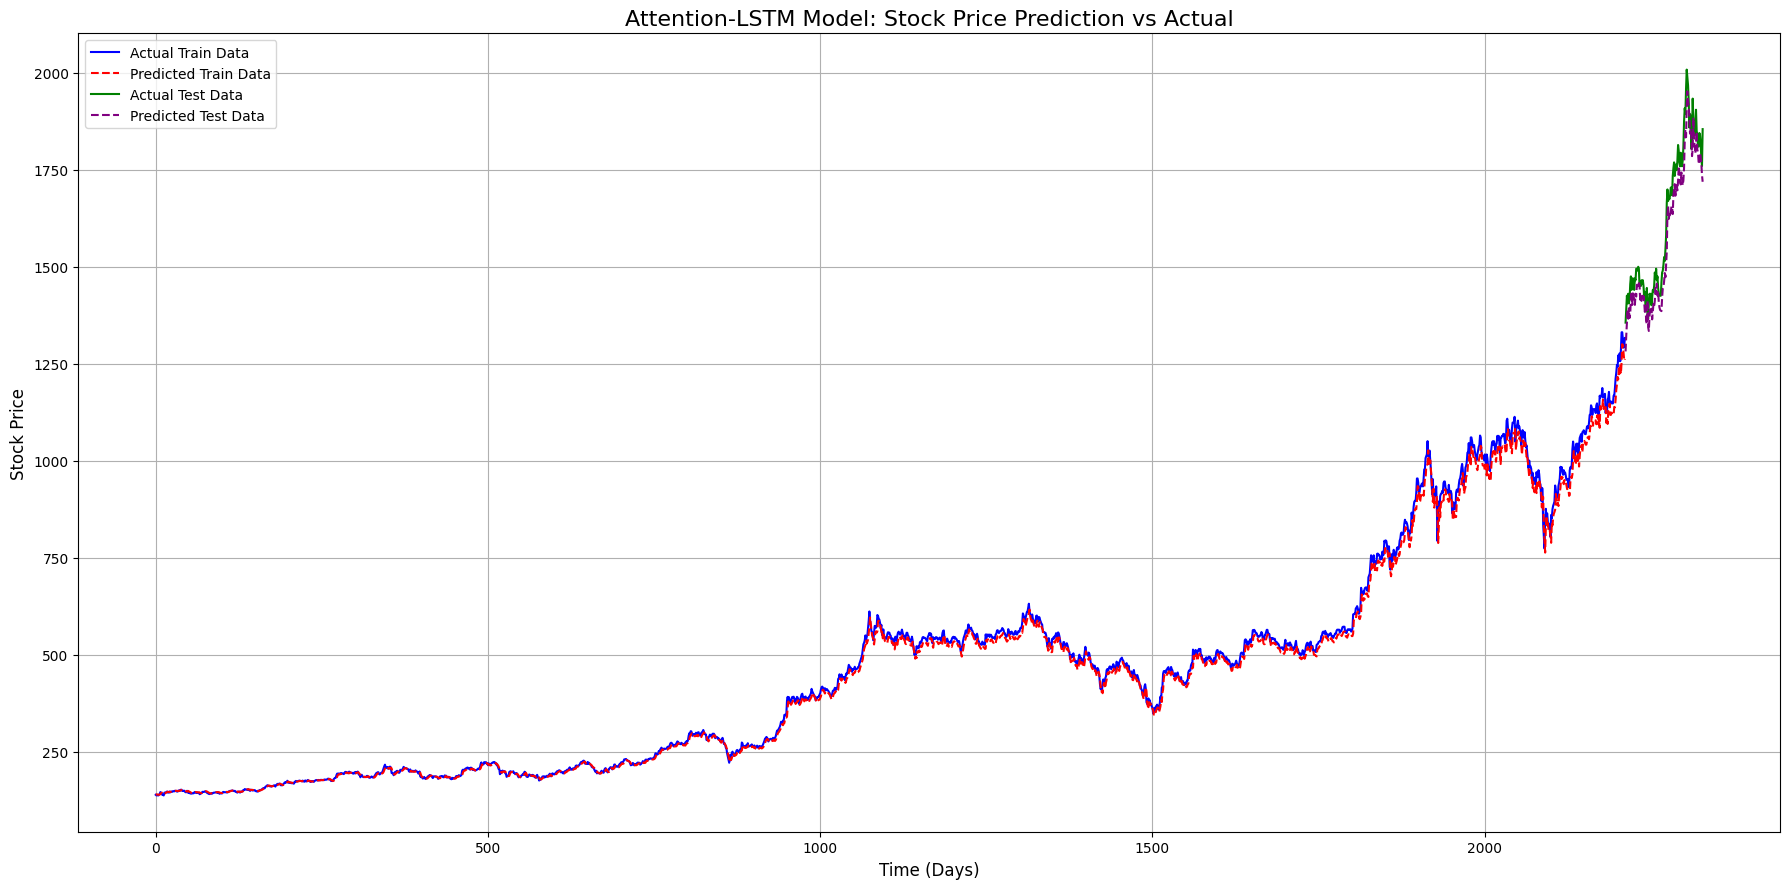

Visualization of Attention-LSTM predictions complete.


In [71]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for the plot
fig, ax = plt.subplots(figsize=(18, 9))

# Plot Actual Train Data
ax.plot(y_train_inverse, label='Actual Train Data', color='blue', linewidth=1.5)

# Plot Predicted Train Data
ax.plot(train_predict_attention, label='Predicted Train Data', color='red', linestyle='--', linewidth=1.5)

# Create an index for the test data that starts after the training data
test_data_indices = range(len(y_train_inverse), len(y_train_inverse) + len(y_test_inverse))

# Plot Actual Test Data
ax.plot(test_data_indices, y_test_inverse, label='Actual Test Data', color='green', linewidth=1.5)

# Plot Predicted Test Data
ax.plot(test_data_indices, test_predict_attention, label='Predicted Test Data', color='purple', linestyle='--', linewidth=1.5)

# Add title and labels
ax.set_title('Attention-LSTM Model: Stock Price Prediction vs Actual', fontsize=16)
ax.set_xlabel('Time (Days)', fontsize=12)
ax.set_ylabel('Stock Price', fontsize=12)

# Add legend
ax.legend(loc='upper left', fontsize=10)

# Add grid
ax.grid(True)

# Display the plot
plt.tight_layout()
plt.show()
print("Visualization of Attention-LSTM predictions complete.")

## Evaluate Attention-LSTM Model Performance

### Subtask:
Calculate and report evaluation metrics, such as Root Mean Squared Error (RMSE), for both the training and testing predictions to quantitatively assess the performance of the Attention-LSTM model. This will provide a clear measure of accuracy.


The Root Mean Squared Error (RMSE) is a commonly used metric to measure the difference between values predicted by a model and the values observed. In the context of stock price prediction, RMSE quantifies the average magnitude of the errors made by the model in predicting stock prices. A lower RMSE value indicates a better fit of the model to the data. It is particularly useful because it gives a relatively high weight to large errors, meaning it is sensitive to outliers. The RMSE values for both the training and testing sets will indicate how well the Attention-LSTM model learned from the historical data and how well it generalizes to unseen data, respectively.

**Reasoning**:
Now that the explanation for RMSE has been provided, I will print the already calculated `train_rmse` and `test_rmse` values to report the evaluation metrics as required by the subtask.



In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero by replacing 0 actual values with a small epsilon or handling them
    # Here we'll just ignore cases where y_true is 0, which might not be ideal for all scenarios
    # For stock prices, 0 is unlikely, but good to be aware.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Filter out zero values in y_true to prevent division by zero
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Or raise an error if no non-zero actual values

    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# Calculate RMSE for training data
train_rmse = np.sqrt(mean_squared_error(y_train_inverse, train_predict_attention))

# Calculate MAE for training data
train_mae = mean_absolute_error(y_train_inverse, train_predict_attention)

# Calculate MAPE for training data
train_mape = mean_absolute_percentage_error(y_train_inverse, train_predict_attention)

# Calculate RMSE for testing data
test_rmse = np.sqrt(mean_squared_error(y_test_inverse, test_predict_attention))

# Calculate MAE for testing data
test_mae = mean_absolute_error(y_test_inverse, test_predict_attention)

# Calculate MAPE for testing data
test_mape = mean_absolute_percentage_error(y_test_inverse, test_predict_attention)

print("Attention-LSTM Model Performance Metrics:")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Train MAPE: {train_mape:.2f}%")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")

Attention-LSTM Model Performance Metrics:
Train RMSE: 16.4477
Train MAE: 10.8093
Train MAPE: 2.01%
Test RMSE: 56.8929
Test MAE: 49.2797
Test MAPE: 3.03%


開始進行 Rolling Forecast 模擬...
正在預測第 1 天... 當前歷史資料長度: 100
正在預測第 2 天... 當前歷史資料長度: 101
正在預測第 3 天... 當前歷史資料長度: 102
正在預測第 4 天... 當前歷史資料長度: 103
正在預測第 5 天... 當前歷史資料長度: 104
正在預測第 6 天... 當前歷史資料長度: 105
正在預測第 7 天... 當前歷史資料長度: 106
正在預測第 8 天... 當前歷史資料長度: 107
正在預測第 9 天... 當前歷史資料長度: 108
正在預測第 10 天... 當前歷史資料長度: 109


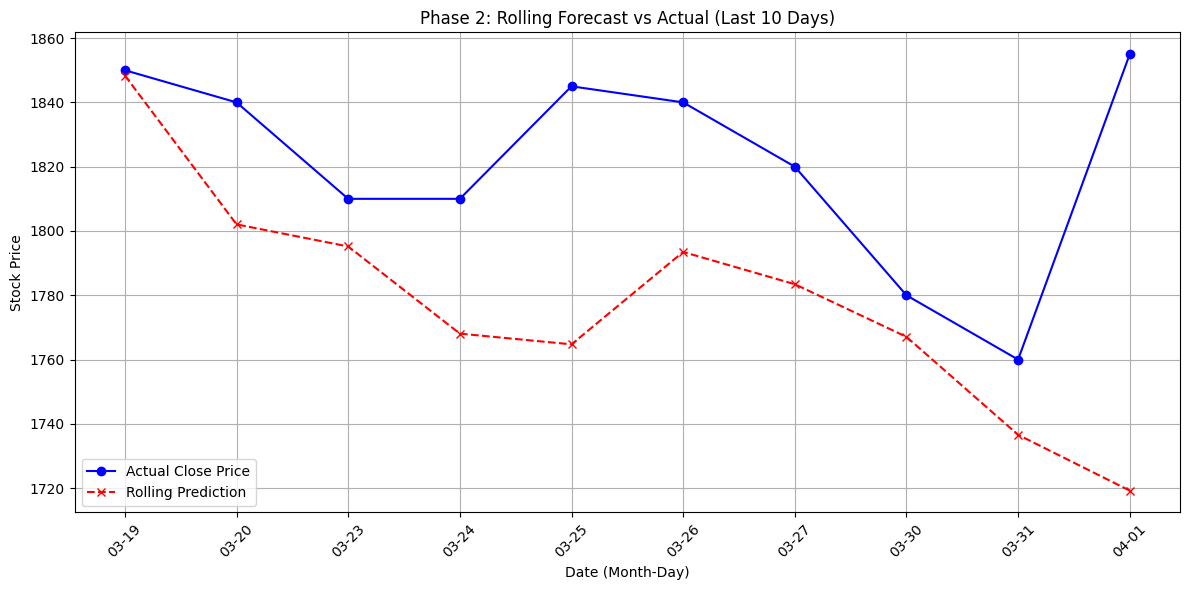

Rolling Forecast MAPE: 2.35%


In [73]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 設定測試期間與提取日期標籤
# ---------------------------------------------------------
forecast_days = 10
look_back = 100 

# 提取最後 10 天的日期，並格式化為 'MM-DD' (或 'YYYY-MM-DD')
# 這裡假設你的 stock_df 索引是日期格式
date_labels = stock_df.index[-forecast_days:].strftime('%m-%d')

# 真實的最後 10 天數據
actual_10_days_scaled = scaled_close_prices[-forecast_days:]

# 模擬起始視窗
current_window = scaled_close_prices[-(forecast_days + look_back) : -forecast_days].copy()

rolling_predictions_scaled = []

print("開始進行 Rolling Forecast 模擬...")

# ---------------------------------------------------------
# 2. 執行逐日預測迴圈
# ---------------------------------------------------------
for i in range(forecast_days):
    print(f"正在預測第 {i+1} 天... 當前歷史資料長度: {len(current_window)}")
    # 步驟 A: 取得當前視窗最後 100 天的資料，並重塑為模型需要的形狀 (1, 100, 1)
    current_input = current_window[-look_back:].reshape(1, look_back, 1)
    
    # 步驟 B: 預測明天的收盤價 (Day t+1)
    pred_price = model_with_attention.predict(current_input, verbose=0)
    rolling_predictions_scaled.append(pred_price[0, 0])
    
    # 步驟 C: 模擬真實世界過了這一天，我們取得了「真實」的收盤價
    true_price = actual_10_days_scaled[i]
    
    # 步驟 D: 將真實價格加入 current_window，視窗往前滾動一天，準備明天的預測
    current_window = np.append(current_window, true_price).reshape(-1, 1)
    
    # （選擇性）作業提到 retrain or update。在實務上，若要每天更新模型權重：
    # X_new = current_window[-look_back-1:-1].reshape(1, look_back, 1)
    # y_new = true_price.reshape(1, 1)
    # model_with_attention.fit(X_new, y_new, epochs=1, batch_size=1, verbose=0)
# ---------------------------------------------------------
# 3. 逆轉換
# ---------------------------------------------------------
rolling_predictions_scaled = np.array(rolling_predictions_scaled).reshape(-1, 1)
rolling_predictions_real = scaler.inverse_transform(rolling_predictions_scaled)
actual_10_days_real = scaler.inverse_transform(actual_10_days_scaled)

# ---------------------------------------------------------
# 4. 繪製圖表 (加上日期標籤)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6)) # 加寬一點方便看日期
plt.plot(actual_10_days_real, marker='o', label='Actual Close Price', color='blue')
plt.plot(rolling_predictions_real, marker='x', linestyle='--', label='Rolling Prediction', color='red')

plt.title('Phase 2: Rolling Forecast vs Actual (Last 10 Days)')
plt.xlabel('Date (Month-Day)')
plt.ylabel('Stock Price')

# === 修改這裡：將原本的 Day 1~10 換成實際日期 ===
plt.xticks(range(forecast_days), labels=date_labels, rotation=45) # rotation=45 防止日期重疊

plt.legend()
plt.grid(True)
plt.tight_layout() # 自動調整佈局避免標籤被切掉
plt.show()

from sklearn.metrics import mean_absolute_percentage_error
rolling_mape = mean_absolute_percentage_error(actual_10_days_real, rolling_predictions_real) * 100
print(f"Rolling Forecast MAPE: {rolling_mape:.2f}%")

In [74]:
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime

# ---------------------------------------------------------
# Phase 3: 每日實況預測 (預測未知的明天)
# ---------------------------------------------------------

# 1. 抓取包含「今天」的最新台積電歷史資料
# (抓最近 6 個月，確保扣除假日後，絕對有超過 100 個交易日)
ticker = "2330.TW"
stock = yf.Ticker(ticker)
recent_data = stock.history(period="6mo")

# 印出最後一天的日期，確認是否有抓到今天的收盤價
latest_date = recent_data.index[-1].strftime('%Y-%m-%d')
today_close = recent_data['Close'].iloc[-1]
print(f"最新資料日期: {latest_date}, 今日真實收盤價: {today_close:.2f}")

# 2. 嚴格取出最後 100 天的收盤價
look_back = 100
latest_100_days = recent_data['Close'].values[-look_back:].reshape(-1, 1)

# 3. 使用你「訓練時擬合好」的 scaler 進行資料縮放
# (注意：這裡用 transform 而不是 fit_transform，因為要用同一套標準)
latest_100_days_scaled = scaler.transform(latest_100_days)

# 4. 重塑為模型需要的 3D 形狀 (1筆資料, 100個時間步, 1個特徵)
X_tomorrow = latest_100_days_scaled.reshape(1, look_back, 1)

# 5. 進行預測
predicted_tomorrow_scaled = model_with_attention.predict(X_tomorrow, verbose=0)

# 6. 將預測結果逆轉換回真實的台幣股價
predicted_tomorrow_price = scaler.inverse_transform(predicted_tomorrow_scaled)
predicted_price = predicted_tomorrow_price[0][0]

print("-" * 30)
print(f"🔮 模型預測明天的台積電收盤價為: {predicted_price:.2f} TWD")
print("-" * 30)

# 7. 簡易策略輔助判斷
if predicted_price > today_close:
    print(f"💡 策略訊號: 模型預期上漲 (+{predicted_price - today_close:.2f}元) -> 建議考慮 【買進 (Buy)】")
elif predicted_price < today_close:
    print(f"💡 策略訊號: 模型預期下跌 ({predicted_price - today_close:.2f}元) -> 建議考慮 【賣出 (Sell)】")
else:
    print("💡 策略訊號: 模型預期持平 -> 建議考慮 【觀望 (Hold)】")

最新資料日期: 2026-04-02, 今日真實收盤價: 1810.00
------------------------------
🔮 模型預測明天的台積電收盤價為: 1761.16 TWD
------------------------------
💡 策略訊號: 模型預期下跌 (-48.84元) -> 建議考慮 【賣出 (Sell)】
